<a href="https://colab.research.google.com/github/LongLongoooo/AIO_233/blob/AIO_Module_5/M05W03_%5BMLP%20-%20Non_linear_Data%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
! gdown --id 1SqSn_8rxkk-Qvu4JLMcN_3ZFGDNa6P_V

/usr/local/lib/python3.10/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1SqSn_8rxkk-Qvu4JLMcN_3ZFGDNa6P_V
To: /content/NonLinear_data.npy
100% 5.57k/5.57k [00:00<00:00, 10.6MB/s]


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [3]:
# Consistent random data settings
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
random_state = 59
np.random.seed(random_state)
torch.manual_seed(random_state)
if torch.cuda.is_available():
  torch.cuda.manual_seed(random_state)

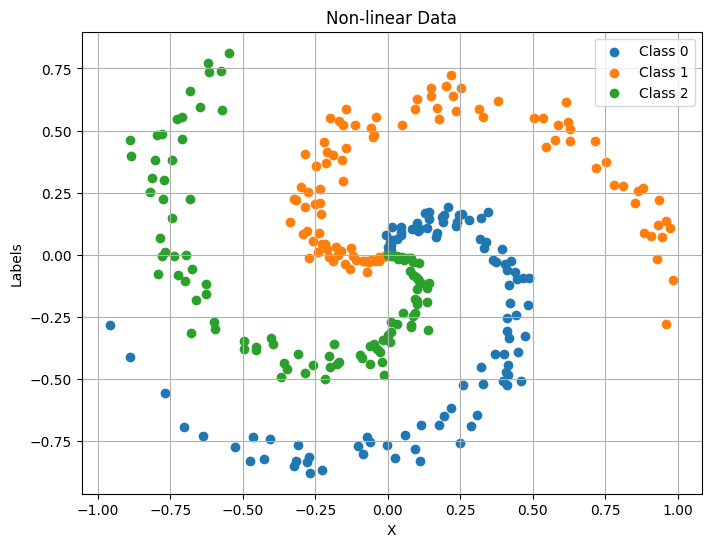

(300, 2) (300,)


In [12]:
data = np.load("/content/NonLinear_data.npy", allow_pickle=True).item()

# Visualize data
y = data["labels"]
X = data["X"]
plt.figure(figsize=(8, 6))
for label in np.unique(y):
    plt.scatter(X[y == label, 0], X[y == label, 1], label=f"Class {label}")

plt.xlabel("X")
plt.ylabel("Labels")
plt.title("Non-linear Data")
plt.legend()
plt.grid(True)
plt.show()
print(X.shape, y.shape)

In [13]:
# Train test split data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=random_state, shuffle=True)
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.125, random_state=random_state, shuffle=True)

# Normalization data
normalizer = StandardScaler()
X_train = normalizer.fit_transform(X_train)
X_val = normalizer.transform(X_val)
X_test = normalizer.transform(X_test)


# Convert to tensor
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

In [14]:
# Construct DataLoader
class CustomDataset(Dataset):
  def __init__(self, X, y):
    self.X = X
    self.y = y

  def __len__(self):
    return len(self.y)

  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]

batch_size = 32
train_dataset = CustomDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = CustomDataset(X_val, y_val)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)

test_dataset = CustomDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)



In [15]:
# Construct
class MLP(nn.Module):
    def __init__(self, input_dims, hidden_dims, output_dims):
        super(MLP, self).__init__()
        self.linear1 = nn.Linear(input_dims, hidden_dims)
        self.output = nn.Linear(hidden_dims, output_dims)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.linear1(x)
        x = self.relu(x)
        out = self.output(x)
        return out.squeeze(1)

input_dims = X_train.shape[1]
hidden_dims = 256
output_dims = np.unique(y_train).shape[0] #[0,1,2]

model = MLP(input_dims=input_dims,
            hidden_dims=hidden_dims,
            output_dims=output_dims).to(device)

print(model)

MLP(
  (linear1): Linear(in_features=2, out_features=256, bias=True)
  (output): Linear(in_features=256, out_features=3, bias=True)
  (relu): ReLU()
)


In [16]:
# Loss function and Optimizer
lr = 0.01
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

# Construct Accuracy function
def accuracy(y_hat, y_true):
  _, y_hat = torch.max(y_hat, dim=1)
  correct = (y_hat==y_true).sum().item()
  accuracy = correct / len(y_true)
  return accuracy

In [17]:
# Training

epochs = 100
train_losses = []
train_accs = []

val_losses = []
val_accs = []

for epoch in range(epochs):
  # Training part
  train_loss = 0.0
  train_target = []
  train_predict = []
  model.train()
  for X_samples, y_samples in (train_loader):
    X_samples = X_samples.type(torch.float32).to(device)
    y_samples = y_samples.to(device)
    optimizer.zero_grad()
    output = model(X_samples)
    loss = criterion(output, y_samples)
    loss.backward()
    optimizer.step()
    train_loss += loss.item()

    train_predict.append(output.detach().cpu())
    train_target.append(y_samples.cpu())

  train_loss /= len(train_loader)
  train_losses.append(train_loss)
  train_predict = torch.cat(train_predict)
  train_target = torch.cat(train_target)
  train_accs.append(accuracy(train_predict, train_target))

  # Valuation part
  val_loss = 0.0
  val_target = []
  val_predict = []
  model.eval()
  with torch.no_grad():
    for X_samples, y_samples in val_loader:
      X_samples = X_samples.to(device)
      y_samples = y_samples.to(device)

      val_output = model(X_samples)

      val_loss += criterion(val_output, y_samples)

      val_predict.append(val_output.cpu())
      val_target.append(y_samples.cpu())

  val_loss /= len(val_loader)
  val_losses.append(val_loss)

  val_predict = torch.cat(val_predict)
  val_target = torch.cat(val_target)
  val_accs.append(accuracy(val_predict, val_target))
  print (f'\ nEPOCH { epoch + 1}:\ tTraining loss : { train_loss :.3f}\tValidation loss : { val_loss :.3f}')

\ nEPOCH 1:\ tTraining loss : 0.814	Validation loss : 0.808
\ nEPOCH 2:\ tTraining loss : 0.622	Validation loss : 0.625
\ nEPOCH 3:\ tTraining loss : 0.503	Validation loss : 0.462
\ nEPOCH 4:\ tTraining loss : 0.394	Validation loss : 0.362
\ nEPOCH 5:\ tTraining loss : 0.346	Validation loss : 0.304
\ nEPOCH 6:\ tTraining loss : 0.266	Validation loss : 0.271
\ nEPOCH 7:\ tTraining loss : 0.248	Validation loss : 0.233
\ nEPOCH 8:\ tTraining loss : 0.227	Validation loss : 0.205
\ nEPOCH 9:\ tTraining loss : 0.189	Validation loss : 0.184
\ nEPOCH 10:\ tTraining loss : 0.158	Validation loss : 0.163
\ nEPOCH 11:\ tTraining loss : 0.145	Validation loss : 0.162
\ nEPOCH 12:\ tTraining loss : 0.136	Validation loss : 0.146
\ nEPOCH 13:\ tTraining loss : 0.120	Validation loss : 0.149
\ nEPOCH 14:\ tTraining loss : 0.130	Validation loss : 0.130
\ nEPOCH 15:\ tTraining loss : 0.108	Validation loss : 0.118
\ nEPOCH 16:\ tTraining loss : 0.105	Validation loss : 0.130
\ nEPOCH 17:\ tTraining loss : 0.

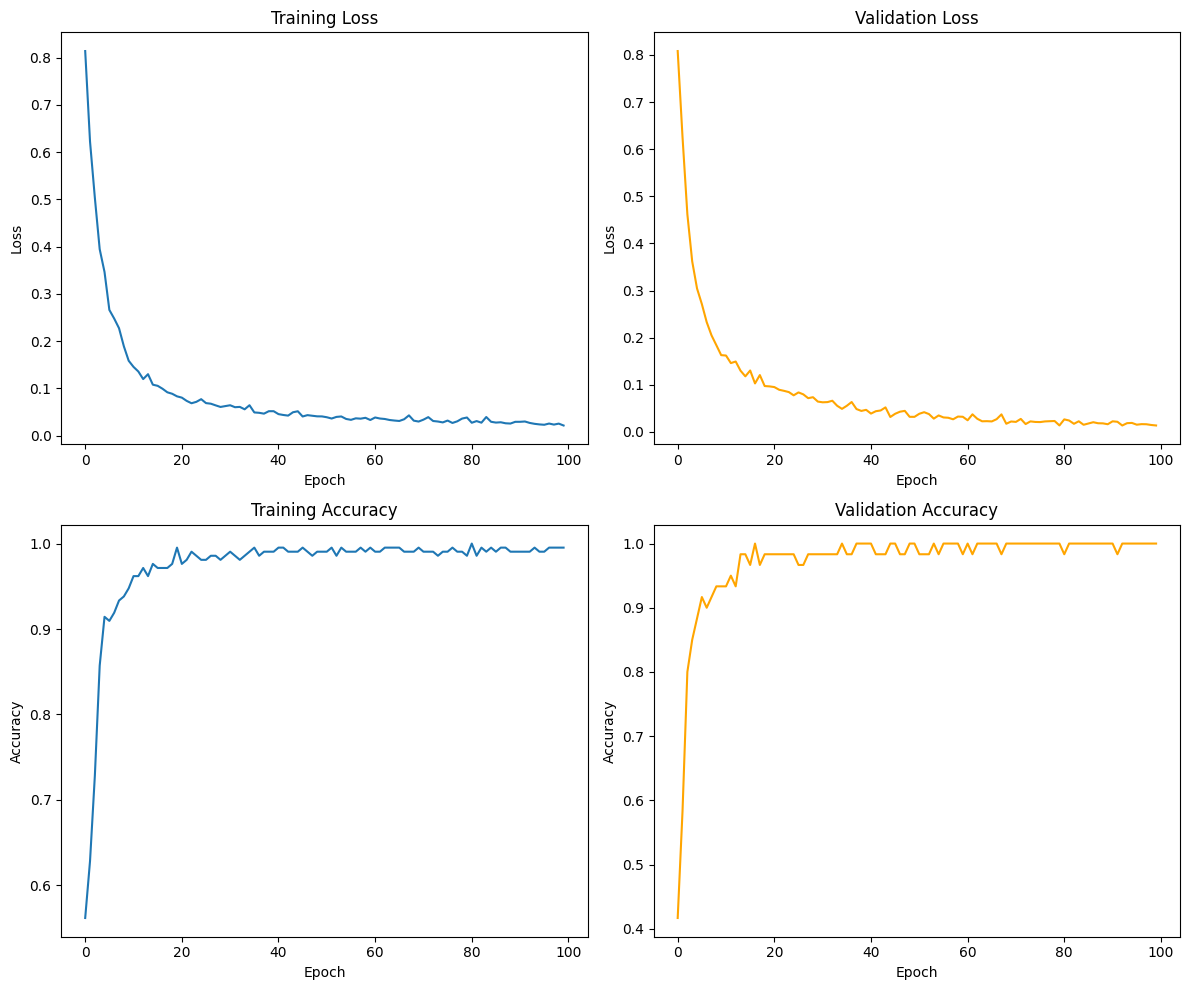

In [18]:
fig, ax = plt.subplots(2, 2, figsize=(12, 10))

ax[0, 0].plot(train_losses)
ax[0, 0].set(xlabel='Epoch', ylabel='Loss')
ax[0, 0].set_title('Training Loss')

ax[0, 1].plot(val_losses, 'orange')
ax[0, 1].set(xlabel='Epoch', ylabel='Loss')
ax[0, 1].set_title('Validation Loss')

ax[1, 0].plot(train_accs)
ax[1, 0].set(xlabel='Epoch', ylabel='Accuracy')
ax[1, 0].set_title('Training Accuracy')

ax[1, 1].plot(val_accs, 'orange')
ax[1, 1].set(xlabel='Epoch', ylabel='Accuracy')
ax[1, 1].set_title('Validation Accuracy')

plt.tight_layout()
plt.show()